# load all

In [1]:
%load_ext autoreload
%autoreload all

In [2]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from functions.utils import load_config
config = load_config() 



In [3]:
df_data = pl.read_csv(config['data_path']['path'] + config['data_path']['data_csv'])
df_concept_info = (pl.read_csv(config['data_path']['path'] + config['data_path']['concept_info'])
                    .rename({"vocabulary_id": "code_type", "concept_name" : "label", "concept_code": "code_value"})
                    .with_columns(pl.col("code_value").cast(pl.String))
                    .select(["code_type", "code_value", "label"])
                    )
df_care_site = pl.read_csv((config['data_path']['path'] + config['data_path']['care_site']),
                           columns=["care_site_id", "care_site_name"])
df_visit = pl.read_csv((config['data_path']['path'] + config['data_path']['visit_occurrence']),
            columns=["visit_occurrence_id", "person_id", "visit_source_value", "care_site_id"])

df_hug_snomed = (pl.read_parquet((config['data_path']['path'] + config['data_path']['hug_snomed_info']), use_pyarrow=True)
                 .with_columns(code_type = pl.lit("SNOMED"))
                 .rename({"id": "code_value"}))

# ontology analysis

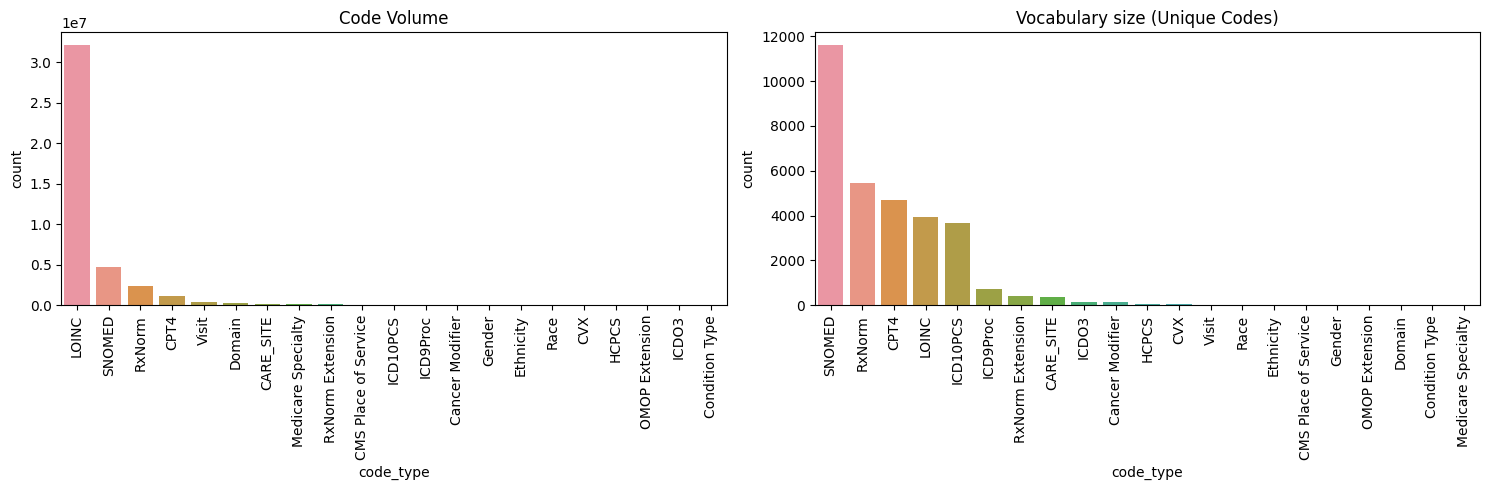

In [4]:
code_volume = (df_data
.with_columns(
    code_type = pl.col("code").str.split("/").list.get(0)
)
["code_type"].value_counts().sort(by = "count", descending=True)
).to_pandas()

code_variability = (df_data
                    .select("code")
                    .unique()
.with_columns(
    code_type = pl.col("code").str.split("/").list.get(0)
)
["code_type"].value_counts().sort(by = "count", descending=True)
).to_pandas()

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=code_volume,
    x="code_type",
    y="count",
    ax=axs[0]
)
axs[0].set_title("Code Volume")
axs[0].tick_params(axis="x", rotation=90)

sns.barplot(
    data=code_variability,
    x="code_type",
    y="count",
    ax=axs[1]
)
axs[1].set_title("Vocabulary size (Unique Codes)")
axs[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


# 0. get data vocabulary and their count

In [5]:
data_vocab = (df_data
.with_columns(
    code_type = pl.col("code").str.split("/").list.get(0),
    code_value = pl.col("code").str.split("/").list.get(1)
)
.select(["code_type", "code_value"])
.group_by(["code_type", "code_value"])
.agg(pl.len().alias("count")))

# 1. check if may SNOMED in data can be mapped to our SNOMED

In [6]:
data_vocab_and_label = data_vocab.join(df_hug_snomed, on= ["code_type","code_value"], how="left")
print(f"Total unique codes: {data_vocab_and_label.height}")
print(f"Total unique codes with labels, directly mappable to our SNOMED: {data_vocab_and_label.filter(pl.col('label').is_not_null()).height}")

Total unique codes: 31122
Total unique codes with labels, directly mappable to our SNOMED: 10693


In [7]:
data_vocab_wo_label = data_vocab_and_label.filter(pl.col("label").is_null()).with_columns(bool_map_direct = pl.lit(False))
data_vocab_w_label = data_vocab_and_label.filter(pl.col("label").is_not_null()).with_columns(bool_map_direct = pl.lit(True))

## 2. For unmappable ones, get their labels from EHRSHOT concept metadata

In [8]:
df_concept_info = (pl.read_csv(config['data_path']['path'] + config['data_path']['concept_info'])
                    .rename({"vocabulary_id": "code_type", "concept_name" : "label", "concept_code": "code_value"})
                    .with_columns(pl.col("code_value").cast(pl.String))
                    .select(["code_type", "code_value", "label"])
                    )

data_vocab_wo_label = data_vocab_wo_label.drop("label").join(df_concept_info, on=["code_type", "code_value"], how="left")

## 3. put both mappable and unmappable together

In [9]:
from pathlib import Path

columns = ["code_type", "code_value", "label", "bool_map_direct", "count"]

# ensure both dataframes contain the same columns (add missing as null)
for name, df in [("w", data_vocab_w_label), ("wo", data_vocab_wo_label)]:
	missing = [c for c in columns if c not in df.columns]
	if missing:
		for c in missing:
			df = df.with_columns(pl.lit(None).alias(c))
	if name == "w":
		data_vocab_w_label = df
	else:
		data_vocab_wo_label = df

data_vocab_w_label = data_vocab_w_label.select(columns)
data_vocab_wo_label = data_vocab_wo_label.select(columns)
data_vocab_w_label_all = data_vocab_w_label.vstack(data_vocab_wo_label)

# build output path robustly (strip leading slash so it is not treated as absolute)
out_path = Path(config['vocab_data']['path']) / config['vocab_data']['concept_with_label_count'].lstrip('/\\')
out_path.parent.mkdir(parents=True, exist_ok=True)

print("Writing to:", out_path)
data_vocab_w_label_all.write_csv(str(out_path))

Writing to: vocab_data_prepare\vocab.parquet
